# TESS Light Curve Analysis: A Pedagogical Tutorial

**TESS** (Transiting Exoplanet Survey Satellite) has been observing nearly the entire sky since 2018,
producing high-cadence photometric time series for millions of stars.
This notebook walks through a complete, research-grade analysis workflow using public TESS data.

### What you will learn

| Section | Topic |
|---------|-------|
| 1 | Querying and downloading TESS light curves from the MAST archive |
| 2 | Cleaning and visualizing raw photometric data |
| 3 | Stitching multi-sector observations |
| 4 | Detecting transits with the **Box Least Squares (BLS)** algorithm |
| 5 | Measuring stellar rotation periods with the **Lomb-Scargle** periodogram |

**Prerequisites:** Basic Python, NumPy, Matplotlib.
**Estimated time:** ~60–90 minutes.

> **Note:** Cells marked 🔧 are hands-on exercises for you to modify.


---
## Part 0: Imports and Setup

We rely on four main packages:

- **`lightkurve`** — high-level interface for Kepler/TESS data; handles queries, downloads, and
  common operations (normalization, folding, periodograms).
- **`astropy`** — units, coordinates, and low-level implementations of BLS and Lomb-Scargle.
- **`astroquery`** — programmatic access to astronomical archives (MAST, Simbad, etc.).
- **`numpy` / `matplotlib`** — numerical arrays and plotting.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

import astropy
import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.timeseries import BoxLeastSquares, LombScargle

import lightkurve as lk
from lightkurve import search_lightcurve

# Inline plots
%matplotlib inline
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 12

print(f"lightkurve : {lk.__version__}")
print(f"astropy    : {astropy.__version__}")


lightkurve : 2.5.0
astropy    : 6.1.3


---
## Part 1: Querying TESS Data from MAST

### 1.1 Background: TESS observing strategy

TESS divides the sky into 26 sectors per hemisphere, each observed continuously for ~27 days.
Each sector is covered by four cameras with a combined 24×96 degree field of view.
Two main data products are relevant here:

- **2-minute cadence** (Short Cadence, SC): pre-selected targets; best for transit searches.
- **20-second cadence** (Fast Cadence): a subset of bright targets; excellent for asteroseismology.
- **10-minute cadence Full Frame Images** (FFI): the entire field of view; useful for rotation studies.

We query the archive using `lightkurve.search_lightcurve`, which talks to the
[MAST](https://mast.stsci.edu) portal behind the scenes.

### 1.2 Choosing a target

For this tutorial we use **HD 209458**, host star of the first transiting hot Jupiter discovered
photometrically (Charbonneau et al. 2000). Its transit properties are well-characterized:

| Parameter | Value |
|-----------|-------|
| Orbital period | 3.5247 days |
| Transit depth | ~1.5 % |
| Transit duration | ~2.9 hours |
| Spectral type | G0V, V = 7.65 |

> 🔧 **Try it:** Replace `"HD 209458"` with any star name (e.g., `"WASP-39"`, `"55 Cnc"`)
> and re-run the notebook.


In [2]:
# ── Target selection ─────────────────────────────────────────────────────────
TRANSIT_TARGET = "HD 209458"

# Search MAST for all available TESS light curves
search_result = search_lightcurve(TRANSIT_TARGET, mission="TESS")
print(search_result)


SearchResult containing 8 data products.

 #     mission     year   author  exptime target_name distance
                                     s                 arcsec 
--- -------------- ---- --------- ------- ----------- --------
  0 TESS Sector 56 2022      SPOC      20   420814525      0.0
  1 TESS Sector 56 2022      SPOC     120   420814525      0.0
  2 TESS Sector 82 2024      SPOC      20   420814525      0.0
  3 TESS Sector 82 2024      SPOC     120   420814525      0.0
  4 TESS Sector 56 2022 TESS-SPOC     200   420814525      0.0
  5 TESS Sector 82 2024 TESS-SPOC     600   420814525      0.0
  6 TESS Sector 56 2022       QLP     200   420814525      0.0
  7 TESS Sector 82 2024       QLP     200   420814525      0.0


The table above lists every available light curve file for our target.
Key columns:

- **`#`** — index used for downloading individual files.
- **`exptime`** — exposure time in seconds (120 s = 2-min cadence).
- **`distance`** — angular separation between our query coordinates and the target centre.
- **`year`** — observation year.

We will start with a single sector to understand the data, then stitch multiple sectors together.


In [3]:
# Download the first result (single sector, 2-min cadence preferred)
# lightkurve returns a LightCurve object
lc_raw = search_result[0].download()

print(type(lc_raw))
print(f"Target label : {lc_raw.label}")
print(f"TESS sector  : {lc_raw.sector}")
print(f"Cadence      : {lc_raw.meta.get('TIMEDEL', '?')} days")
print(f"Time range   : {lc_raw.time.min().value:.3f} – {lc_raw.time.max().value:.3f} BTJD")
print(f"N data points: {len(lc_raw)}")


<class 'lightkurve.lightcurve.TessLightCurve'>
Target label : TIC 420814525
TESS sector  : 56
Cadence      : 0.0002314814814814815 days
Time range   : 2825.262 – 2853.144 BTJD
N data points: 117688


---
## Part 2: Exploring and Cleaning the Light Curve

### 2.1 Plotting the raw light curve

TESS provides several flux columns. The two most common are:

- **`SAP_FLUX`** (Simple Aperture Photometry): raw summed pixel flux — contains instrumental trends.
- **`PDCSAP_FLUX`** (Pre-search Data Conditioning SAP): systematics-corrected flux — use this for
  science.

`lightkurve` defaults to `PDCSAP_FLUX` when available.


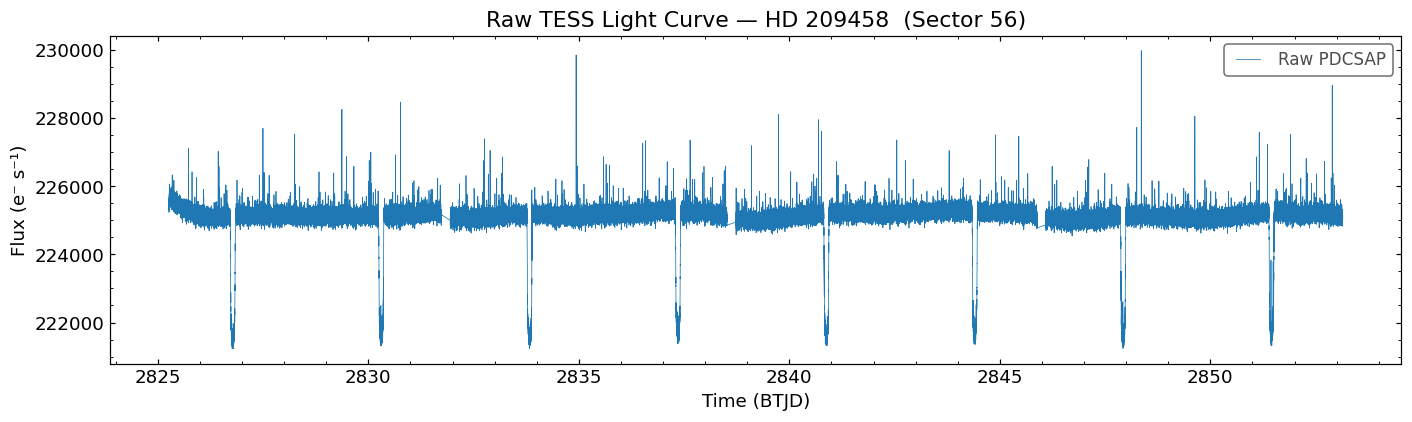

In [4]:
fig, ax = plt.subplots(figsize=(13, 4))
lc_raw.plot(ax=ax, label="Raw PDCSAP")
ax.set_title(f"Raw TESS Light Curve — {TRANSIT_TARGET}  (Sector {lc_raw.sector})")
ax.set_xlabel("Time (BTJD)")
ax.set_ylabel("Flux (e⁻ s⁻¹)")
plt.tight_layout()
plt.show()


### 2.2 Cleaning: NaN removal, normalization, sigma-clipping

Raw light curves contain:
- **NaN values** from momentum dumps (spacecraft reaction wheel resets) or data gaps.
- **Outlier points** from cosmic rays or short-duration systematics.
- **Absolute flux units** (e⁻ s⁻¹) — we normalize to unit median for easier comparison.

We apply three operations in sequence, inspecting the result after each step.


In [5]:
# Step 1: Remove NaN flux values
lc_nonan = lc_raw.remove_nans()
print(f"After NaN removal : {len(lc_nonan):5d} points  (removed {len(lc_raw) - len(lc_nonan)})")

# Step 2: Normalize flux to median = 1
lc_norm = lc_nonan.normalize()
print(f"After normalization: flux median = {np.nanmedian(lc_norm.flux.value):.4f}")

# Step 3: Sigma-clip outliers 
lc_clean = lc_norm.remove_outliers(sigma_lower=float('inf'), sigma_upper=5)
print(f"After sigma-clip   : {len(lc_clean):5d} points  (removed {len(lc_norm) - len(lc_clean)})")


After NaN removal : 117688 points  (removed 0)
After normalization: flux median = 1.0000
After sigma-clip   : 117683 points  (removed 5)


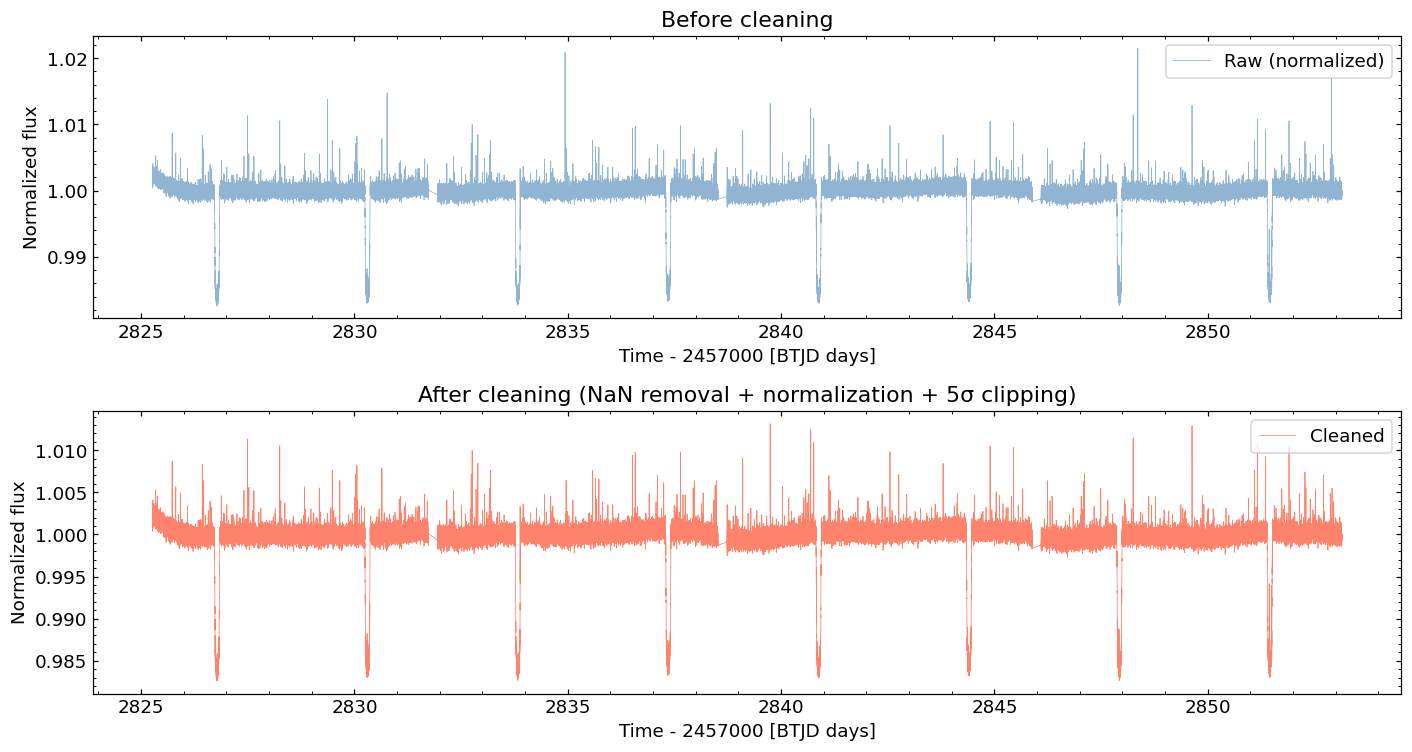

In [6]:
# Compare raw vs cleaned
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=False)

lc_raw.normalize().plot(ax=axes[0], color='steelblue', alpha=0.6, label='Raw (normalized)')
axes[0].set_title("Before cleaning")
axes[0].set_ylabel("Normalized flux")

lc_clean.plot(ax=axes[1], color='tomato', alpha=0.8, label='Cleaned')
axes[1].set_title("After cleaning (NaN removal + normalization + 5σ clipping)")
axes[1].set_ylabel("Normalized flux")

for ax in axes:
    ax.legend(loc='upper right')

plt.tight_layout()
plt.show()


---
## Part 3: Stitching Multiple Sectors

A single TESS sector spans only ~27 days. For long-period signals (or to improve statistics
on short-period signals) we combine multiple sectors. `lightkurve` makes this straightforward
with `download_all()` and `stitch()`.

**Caveat:** each sector is processed independently by the TESS pipeline, so flux levels and
instrumental systematics can differ. The `stitch()` method normalizes each sector before joining,
mitigating this effect.


In [7]:
# Download all available 2-minute cadence light curves
# This may take a minute depending on how many sectors are available
lc_collection = search_result[search_result.exptime == 120].download_all()
print(f"Downloaded {len(lc_collection)} sectors")
print(lc_collection)


Downloaded 1 sectors
LightCurveCollection of 1 objects:
    0: <TessLightCurve LABEL="TIC 420814525" SECTOR=56 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>


Total time span : 27.9 days
Total data points: 117683


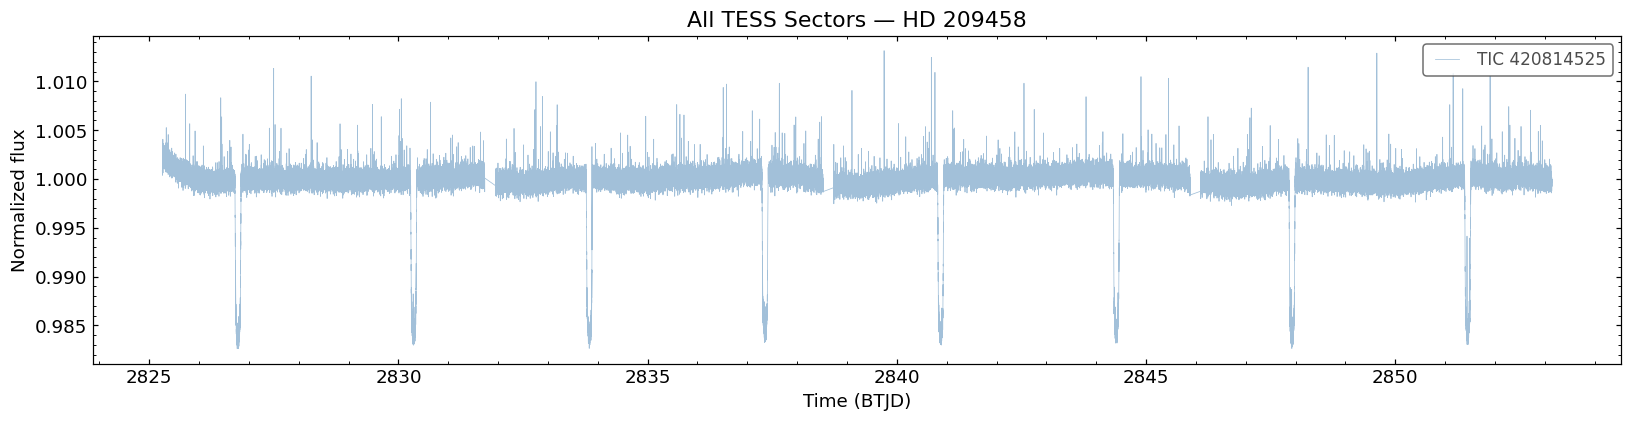

In [8]:
# Stitch sectors into one continuous light curve, then clean
lc_all = (lc_collection
          .stitch()
          .remove_nans()
          .normalize()
          .remove_outliers(sigma_upper=5.0, sigma_lower=float('inf')))

print(f"Total time span : {lc_all.time.max().value - lc_all.time.min().value:.1f} days")
print(f"Total data points: {len(lc_all)}")

fig, ax = plt.subplots(figsize=(15, 4))
lc_all.plot(ax=ax, color='steelblue', alpha=0.5)
ax.set_title(f"All TESS Sectors — {TRANSIT_TARGET}")
ax.set_xlabel("Time (BTJD)")
ax.set_ylabel("Normalized flux")
plt.tight_layout()
plt.show()


The vertical discontinuities between sectors are normal — they reflect the ~5-day gaps when
TESS downlinks data to Earth and re-points its cameras.


---
## Part 4: Detecting Transits with Box Least Squares (BLS)

### 4.1 Algorithm overview

The **Box Least Squares** algorithm (Kovács, Zucker & Mazeh 2002) searches for periodic,
box-shaped dips in a time series. It is the standard method for blind transit searches.

For each trial period $P$ and transit duration $\delta$, BLS fits a model of the form:

$$
f(t) = \begin{cases} 1 - d & \text{if } t \bmod P \in [t_0, t_0 + \delta] \\ 1 & \text{otherwise} \end{cases}
$$

where $d$ is the transit depth and $t_0$ is the transit midpoint.
The **BLS power** quantifies how much variance is explained by the box model.

**Key parameters to set:**
- Period range `[P_min, P_max]`: informed by your science case.
  Rule of thumb: $P_\mathrm{max} < T_\mathrm{obs}/2$ to see at least two transits.
- Transit duration range: typically 0.5–12 hours for hot Jupiters.

### 4.2 Running BLS with lightkurve

`lightkurve` wraps `astropy.timeseries.BoxLeastSquares` via its `to_periodogram` method,
which returns a `BLSPeriodogram` object with convenient plotting and access methods.


In [9]:
# Use the single-sector cleaned light curve for clarity first.
# BLS period search — adjust range based on expected signal
P_min = 1.0   # days
P_max = 10.0  # days (well within the ~27-day sector)

print(f"Searching periods {P_min}–{P_max} days ...")

bls_pg = lc_clean.to_periodogram(
    method='bls',
    minimum_period=P_min,
    maximum_period=P_max,
    frequency_factor=1.0,      # controls period grid density (higher = finer grid)
)

# Best-fit parameters
best_period   = bls_pg.period_at_max_power          # Quantity (days)
best_t0       = bls_pg.transit_time_at_max_power    # Time object (BTJD)
best_duration = bls_pg.duration_at_max_power        # Quantity (days)
best_depth    = bls_pg.depth_at_max_power

# Extract numeric BTJD value from the Time object for use with astropy BLS
best_t0_val   = best_t0.value                       # float, BTJD days

print(f"\nBLS Results")
print(f"  Best period   : {best_period:.5f}")
print(f"  Transit time  : {best_t0_val:.5f} BTJD")
print(f"  Duration      : {best_duration.to(u.hour):.3f}")
print(f"  Depth         : {best_depth:.5f}")
print(f"  Max BLS power : {bls_pg.max_power:.2f}")


Searching periods 1.0–10.0 days ...

BLS Results
  Best period   : 3.52488 d
  Transit time  : 2826.78205 BTJD
  Duration      : 2.400 h
  Depth         : 0.01478
  Max BLS power : 1461677.14


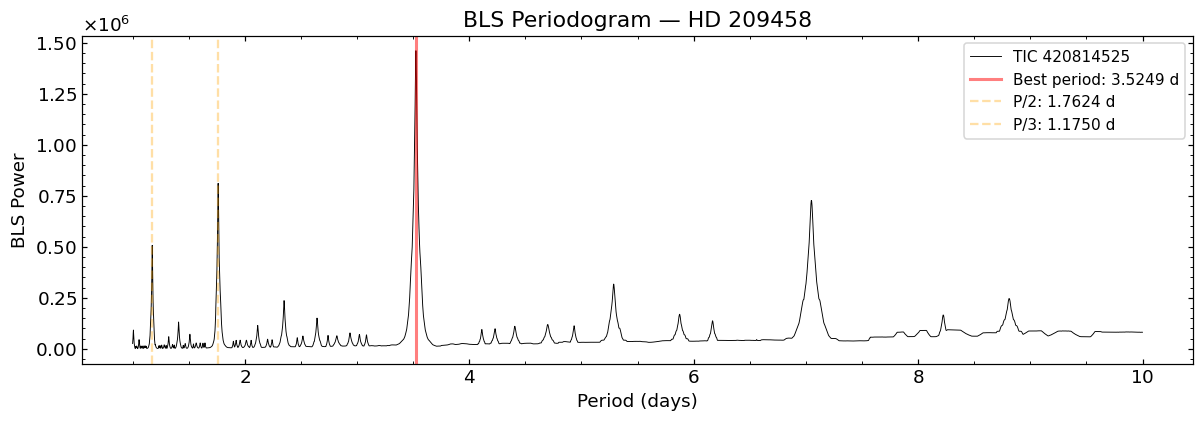

In [10]:
# Plot the BLS periodogram
fig, ax = plt.subplots(figsize=(11, 4))
bls_pg.plot(ax=ax, color='k', lw=0.6)
ax.axvline(best_period.value, color='red', alpha=0.5, lw=2,
           label=f"Best period: {best_period:.4f}")  # .value strips Quantity units for plotting

# Mark harmonics / aliases
for n in [2, 3]:
    ax.axvline((best_period / n).value, color='orange', alpha=0.35, lw=1.5, ls='--',
               label=f"P/{n}: {(best_period/n):.4f}")

ax.legend(fontsize=10)
ax.set_title(f"BLS Periodogram — {TRANSIT_TARGET}")
ax.set_xlabel("Period (days)")
ax.set_ylabel("BLS Power")
plt.tight_layout()
plt.show()


**Interpreting the periodogram:**

- The tallest peak gives the best-fit period. For HD 209458 b you should find $P \approx 3.525$ days.
- Peaks at $P/2$, $P/3$ (harmonics) are alias signals — one transit period folding onto a shorter period.
- A **high, narrow, isolated** peak is a good transit candidate. A broad, messy periodogram may
  indicate stellar variability or systematics rather than a transit.


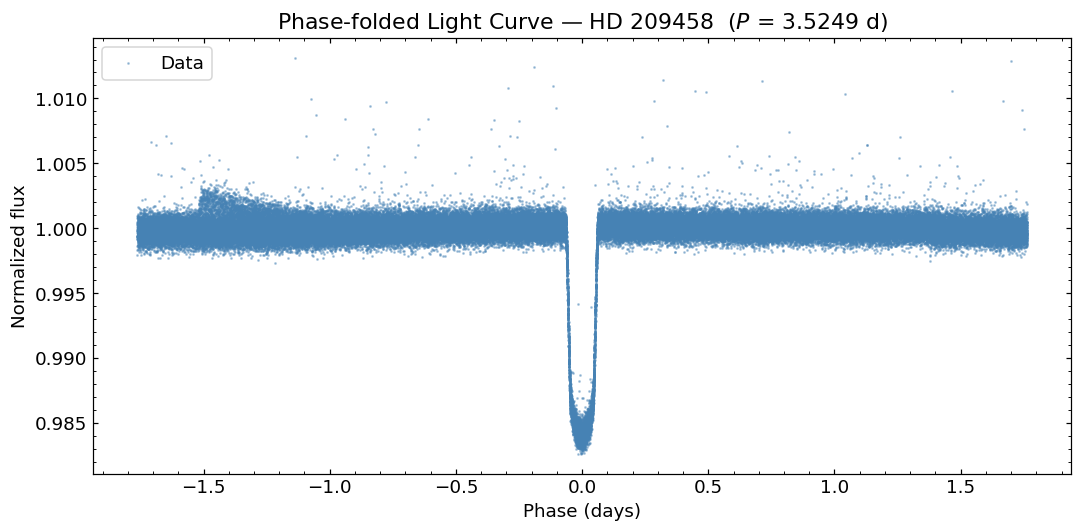

In [11]:
# Phase-fold the light curve on the best period
# epoch_time accepts either a Time object or a float (BTJD); both work in lightkurve >= 2.0
lc_folded = lc_clean.fold(period=best_period, epoch_time=best_t0)

fig, ax = plt.subplots(figsize=(10, 5))

# Scatter all data points (small, semi-transparent)
lc_folded.scatter(ax=ax, s=3, alpha=0.4, color='steelblue', label='Data')


ax.set_title(f"Phase-folded Light Curve — {TRANSIT_TARGET}  ($P$ = {best_period:.4f})")
ax.set_xlabel("Phase (days)")
ax.set_ylabel("Normalized flux")
ax.legend()
plt.tight_layout()
plt.show()


### 4.3 Overlaying a transit model model




Out-of-transit rms: 695 ppm  (103856 points)

batman best-fit transit parameters
  Rp/R*           : 0.12064
  Transit depth   : 1.4554  %
  a/R*            : 8.836
  Inclination     : 86.6732  deg
  Impact param b  : 0.5128
  t0 offset       : -2.32  min  (from BLS epoch)
  T14 duration    : 3.043  hours
  LD coefficients : u1=0.3624903269560166, u2=0.08167076493217051  (fixed, quadratic)
  chi² / N        : 0.9911
  Converged       : True


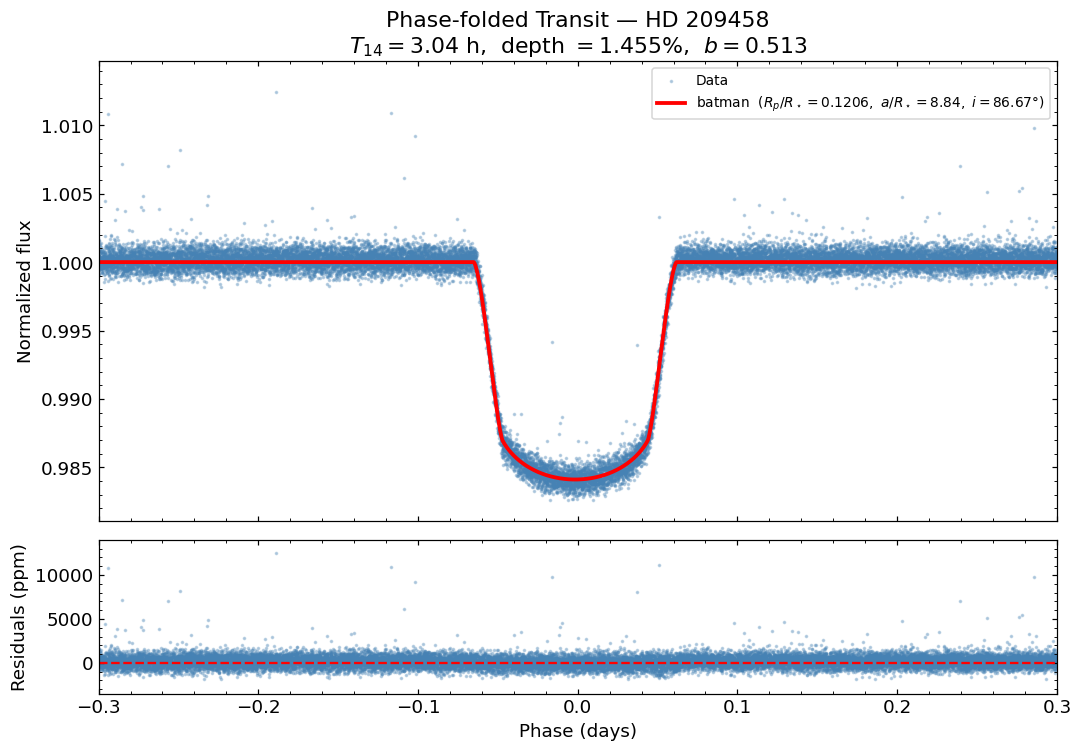


Residual rms : 690 ppm


In [16]:
# ── Fit a batman transit model to the phase-folded data ──────────────────────
# Implements the Mandel & Agol (2002) analytic limb-darkened transit model.
# Reference: Kreidberg 2015, PASP 127, 1161

import batman
from scipy.optimize import minimize

time = lc_clean.time.value   # BTJD days
flux = lc_clean.flux.value


P_days = best_period.to(u.day).value

# Phase relative to transit center, in days ([-P/2, +P/2])
# Derived directly from the raw time array to avoid lightkurve unit ambiguity.
phase_raw = (time - best_t0_val) % P_days
phase_all = np.where(phase_raw > P_days / 2, phase_raw - P_days, phase_raw)

# ── Initial guesses from BLS ──────────────────────────────────────────────────
k0      = np.sqrt(np.abs(best_depth))           # Rp/R*  from transit depth
T_dur   = best_duration.to(u.day).value         # transit duration [days]
aR0     = P_days / (np.pi * T_dur)             # a/R*   (impact parameter b=0 approximation)
inc0    = 88.0                                  # inclination [deg]
t0_off0 = 0.0                                  # t0 offset from BLS centre [days]
u10 = 0.3                                       # limb darkening u1 (quadratic)
u20 = 0.1                                       # limb darkening u2 (quadratic)

# ── Flux uncertainty from out-of-transit scatter ──────────────────────────────
oot_mask = np.abs(phase_all) > 2 * T_dur
sigma    = np.std(flux[oot_mask]) if oot_mask.sum() > 20 else 1e-3
print(f"Out-of-transit rms: {sigma*1e6:.0f} ppm  ({oot_mask.sum()} points)")

# ── Limb darkening (quadratic, fixed) ────────────────────────────────────────
# For a solar-type star in the TESS bandpass; set from atmosphere models

def batman_flux(t_phase, k, aR, inc, t0_off, u1, u2):
    """Evaluate batman quadratic-LD transit model at phase times (days)."""
    p           = batman.TransitParams()
    p.t0        = t0_off        # transit centre within the phase array
    p.per       = P_days
    p.rp        = k             # Rp/R*
    p.a         = aR            # a/R*
    p.inc       = inc           # degrees
    p.ecc       = 0.0           # circular orbit
    p.w         = 90.0
    p.u         = [u1, u2]
    p.limb_dark = "quadratic"
    return batman.TransitModel(p, t_phase).light_curve(p)

def chi2(theta):
    k, aR, inc, t0_off, u1, u2 = theta
    if not (0 < k < 0.5):       return 1e10   # unphysical radius ratio
    if not (1.5 < aR < 200):    return 1e10   # unphysical semi-major axis
    if not (60 < inc <= 90.5):  return 1e10   # unphysical inclination
    model = batman_flux(phase_all, k, aR, inc, t0_off, u1, u2)
    return np.sum(((flux - model) / sigma) ** 2)

# ── Optimization (Nelder-Mead; no gradients needed) ──────────────────────────
# For science-grade results replace with emcee or dynesty to get posteriors.
result = minimize(
    chi2, [k0, aR0, inc0, t0_off0, u10, u20],
    method='Nelder-Mead',
    options={'maxiter': 30000, 'xatol': 1e-8, 'fatol': 1e-9, 'adaptive': True},
)
k_fit, aR_fit, inc_fit, t0_fit, u1_fit, u2_fit = result.x

# ── Derived parameters ────────────────────────────────────────────────────────
depth_fit = k_fit ** 2
b_fit     = aR_fit * np.cos(np.radians(inc_fit))              # impact parameter
T14_fit   = (P_days / np.pi) * np.arcsin(
                (1.0 / aR_fit) * np.sqrt((1 + k_fit)**2 - b_fit**2)
            ) * 24                                             # hours

print()
print("batman best-fit transit parameters")
print("=" * 44)
print(f"  Rp/R*           : {k_fit:.5f}")
print(f"  Transit depth   : {depth_fit*100:.4f}  %")
print(f"  a/R*            : {aR_fit:.3f}")
print(f"  Inclination     : {inc_fit:.4f}  deg")
print(f"  Impact param b  : {b_fit:.4f}")
print(f"  t0 offset       : {t0_fit * 24 * 60:.2f}  min  (from BLS epoch)")
print(f"  T14 duration    : {T14_fit:.3f}  hours")
print(f"  LD coefficients : u1={u1_fit}, u2={u2_fit}  (fixed, quadratic)")
print(f"  chi² / N        : {result.fun / len(flux):.4f}")
print(f"  Converged       : {result.success}")

# ── Plot ──────────────────────────────────────────────────────────────────────
# Smooth model on a fine phase grid
phase_fine  = np.linspace(-3 * T_dur, 3 * T_dur, 5000)
flux_batman = batman_flux(phase_fine, k_fit, aR_fit, inc_fit, t0_fit, u1_fit, u2_fit)

# Manual binning of the raw phase-folded scatter
sort_idx   = np.argsort(phase_all)
ph_s, fl_s = phase_all[sort_idx], flux[sort_idx]
n_bins     = 60
edges      = np.linspace(ph_s.min(), ph_s.max(), n_bins + 1)
mids       = 0.5 * (edges[:-1] + edges[1:])
bin_flux   = [np.nanmedian(fl_s[(ph_s >= edges[i]) & (ph_s < edges[i+1])])
              for i in range(n_bins)]

fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True,
                         gridspec_kw={'height_ratios': [3, 1]})

# Top panel: data + model
axes[0].scatter(phase_all, flux, s=2, alpha=0.3, color='steelblue', label='Data')
axes[0].plot(phase_fine, flux_batman, 'r-', lw=2.5,
             label=r'batman  ($R_p/R_\star={:.4f},\ a/R_\star={:.2f},\ i={:.2f}°$)'.format(
                 k_fit, aR_fit, inc_fit))
axes[0].set_ylabel("Normalized flux")
axes[0].set_title(f"Phase-folded Transit — {TRANSIT_TARGET}"
                  f"\n$T_{{14}} = {T14_fit:.2f}$ h,  depth $= {depth_fit*100:.3f}$%,"
                  f"  $b = {b_fit:.3f}$")
axes[0].legend(fontsize=9)
axes[0].set_xlim(-3 * T_dur, 3 * T_dur)

# Bottom panel: residuals
model_at_data = batman_flux(phase_all, k_fit, aR_fit, inc_fit, t0_fit, u1_fit, u2_fit)
residuals     = (flux - model_at_data) * 1e6   # ppm
axes[1].scatter(phase_all, residuals, s=2, alpha=0.3, color='steelblue')
axes[1].axhline(0, color='red', lw=1.5, ls='--')
axes[1].set_xlabel("Phase (days)")
axes[1].set_ylabel("Residuals (ppm)")
axes[1].set_xlim(-3 * T_dur, 3 * T_dur)

plt.tight_layout()
plt.show()

print(f"\nResidual rms : {np.std(residuals):.0f} ppm")


**Physical interpretation of transit depth:**

For a uniform-brightness star, the transit depth $\delta$ relates to the planet-to-star radius ratio:

$$
\delta \approx \left(\frac{R_\mathrm{p}}{R_\star}\right)^2
$$

> 🔧 **Exercise:** Using the measured depth, compute $R_\mathrm{p}/R_\star$ for HD 209458 b.
> HD 209458 has $R_\star \approx 1.2\,R_\odot$. What radius do you get for the planet?
> Compare to the literature value of $R_\mathrm{p} \approx 1.4\,R_\mathrm{Jup}$.


---
## Part 5: Stellar Rotation Periods with the Lomb-Scargle Periodogram

### 5.1 Stellar rotation in photometric data

Active stars have magnetic starspots — cooler, darker regions on the photosphere.
As the star rotates, spots move in and out of view, producing quasi-sinusoidal flux modulations
with the rotation period $P_\mathrm{rot}$.

Unlike transits (sharp boxes), rotation signals are:
- **Quasi-periodic**: spot lifetimes are finite, so the signal drifts in phase.
- **Multi-harmonic**: complex spot patterns produce power at $P_\mathrm{rot}$ and its harmonics.
- **Variable in amplitude**: spot coverage changes on activity cycle timescales.

### 5.2 The Lomb-Scargle periodogram

For unevenly sampled data, the Lomb-Scargle periodogram (Lomb 1976; Scargle 1982) is
the standard tool. It is equivalent to fitting sinusoids of the form

$$
f(t) = A\cos(2\pi t / P) + B\sin(2\pi t / P) + C
$$

at each trial period and measuring the improvement in $\chi^2$.
The normalized **Lomb-Scargle power** lies in $[0, 1]$: values near 1 indicate a very
significant sinusoidal signal.

**False alarm probability (FAP):** the probability that a given power level arises from noise alone.
We use FAP < 0.1 % as our detection threshold.

### 5.3 Target: AU Microscopii

For this section we switch to **AU Mic** — a young (22 Myr) M-dwarf at 9.7 pc,
famous for its edge-on debris disk, two confirmed transiting planets, and strong stellar activity.

| Parameter | Value |
|-----------|-------|
| Spectral type | M1Ve |
| $V$ magnitude | 8.6 |
| Rotation period | ~4.84 days |
| Age | ~22 Myr |


In [17]:
ROTATION_TARGET = "AU Mic"

# Search for TESS 2-minute cadence data
search_rot = search_lightcurve(ROTATION_TARGET, mission="TESS", exptime=120)
print(search_rot)


SearchResult containing 4 data products.

 #     mission     year author exptime target_name distance
                                  s                 arcsec 
--- -------------- ---- ------ ------- ----------- --------
  0 TESS Sector 01 2018   SPOC     120   441420236      0.0
  1 TESS Sector 27 2020   SPOC     120   441420236      0.0
  2 TESS Sector 95 2025   SPOC     120   441420236      0.0
  3 TESS Sector 01 2018  TASOC     120   441420236      0.0


Sector      : 1
Time span   : 27.1 days
Data points : 17707


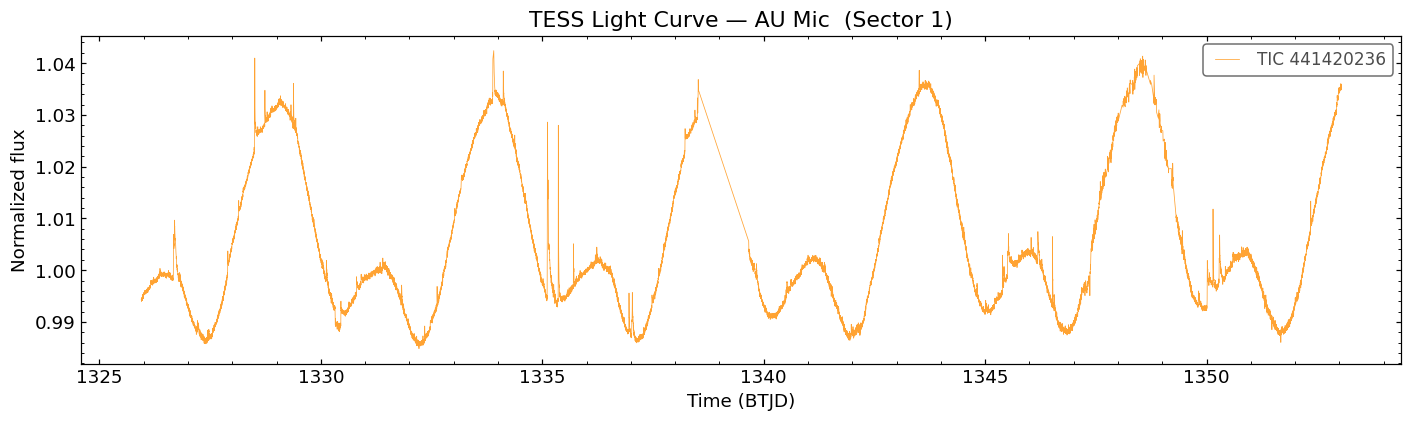

In [19]:
# Download first sector
lc_rot_raw = search_rot[0].download()

# Clean: use tighter sigma clip (3σ) to catch flares as outliers
# Note: flares are real astrophysical signals on AU Mic — we remove them here
# because we care only about the rotational modulation.
lc_rot = (lc_rot_raw
          .remove_nans()
          .normalize()
          .remove_outliers(sigma=3.0))   # 3σ to catch bright flare peaks

print(f"Sector      : {lc_rot_raw.sector}")
print(f"Time span   : {lc_rot.time.max().value - lc_rot.time.min().value:.1f} days")
print(f"Data points : {len(lc_rot)}")

fig, ax = plt.subplots(figsize=(13, 4))
lc_rot.plot(ax=ax, color='darkorange', alpha=0.8)
ax.set_title(f"TESS Light Curve — {ROTATION_TARGET}  (Sector {lc_rot_raw.sector})")
ax.set_xlabel("Time (BTJD)")
ax.set_ylabel("Normalized flux")
plt.tight_layout()
plt.show()


The large-amplitude, smoothly varying modulation is the rotational signal.
The sharp upward spikes are **stellar flares** — magnetic reconnection events.
At 3σ clipping most flare peaks are removed; what remains is the rotational envelope.

### 5.4 Computing the Lomb-Scargle periodogram


In [20]:
time_rot = lc_rot.time.value   # days
flux_rot = lc_rot.flux.value

# Period search range
P_rot_min = 1.0    # days — avoid short-period aliases
P_rot_max = 20.0   # days — constrained by sector length (~27 d / 2)

freq_min = 1.0 / P_rot_max   # day^-1
freq_max = 1.0 / P_rot_min   # day^-1

# Instantiate LS object
ls = LombScargle(time_rot, flux_rot)

# Compute power on a fine frequency grid (50 samples per peak is standard)
frequency, power = ls.autopower(
    minimum_frequency=freq_min,
    maximum_frequency=freq_max,
    samples_per_peak=50,
)
periods = 1.0 / frequency   # convert frequency grid to period

# Best period
best_freq_idx    = np.argmax(power)
best_rot_period  = periods[best_freq_idx]
best_rot_power   = power[best_freq_idx]

# False alarm probability at the peak
fap_levels = ls.false_alarm_level([0.1, 0.01, 0.001])   # 10%, 1%, 0.1% FAP thresholds

print(f"Best rotation period : {best_rot_period:.4f} days")
print(f"Peak LS power        : {best_rot_power:.4f}")
print(f"FAP thresholds       : 10% → {fap_levels[0]:.4f}")
print(f"                        1% → {fap_levels[1]:.4f}")
print(f"                       0.1% → {fap_levels[2]:.4f}")


Best rotation period : 4.8439 days
Peak LS power        : 0.6532
FAP thresholds       : 10% → 0.0016
                        1% → 0.0019
                       0.1% → 0.0022


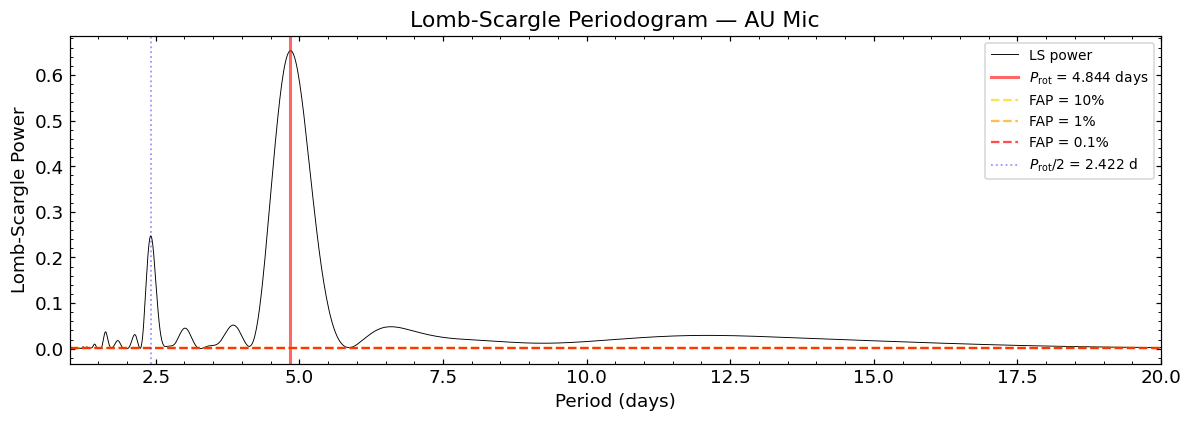

In [21]:
# Plot the Lomb-Scargle periodogram
fig, ax = plt.subplots(figsize=(11, 4))

ax.plot(periods, power, 'k-', lw=0.6, label='LS power')
ax.axvline(best_rot_period, color='red', lw=2, alpha=0.6,
           label=f"$P_\\mathrm{{rot}}$ = {best_rot_period:.3f} days")

# Overplot FAP threshold lines
fap_labels = ['FAP = 10%', 'FAP = 1%', 'FAP = 0.1%']
fap_colors = ['gold', 'orange', 'red']
for level, label, color in zip(fap_levels, fap_labels, fap_colors):
    ax.axhline(level, ls='--', color=color, alpha=0.7, label=label)

# Mark harmonics
for n in [2]:
    p_harmonic = best_rot_period / n
    ax.axvline(p_harmonic, color='blue', lw=1.2, alpha=0.4, ls=':',
               label=f"$P_\\mathrm{{rot}}/2$ = {p_harmonic:.3f} d")

ax.set_xlabel("Period (days)")
ax.set_ylabel("Lomb-Scargle Power")
ax.set_title(f"Lomb-Scargle Periodogram — {ROTATION_TARGET}")
ax.set_xlim(P_rot_min, P_rot_max)
ax.legend(fontsize=9, loc='upper right')
plt.tight_layout()
plt.show()


**Interpreting the LS periodogram:**

- The dominant peak should sit near $P_\mathrm{rot} \approx 4.84$ days for AU Mic.
- If the peak lies at $\approx 2.4$ days, you found the **first harmonic** ($P_\mathrm{rot}/2$) —
  this happens when two antipodal spot groups produce two dips per rotation.
- All peaks should lie well above the 0.1% FAP line, confirming a highly significant detection.

> 🔧 **Exercise:** Try `sigma=5.0` instead of `sigma=3.0` in the sigma-clipping step.
> How does including flares in the time series affect the periodogram?


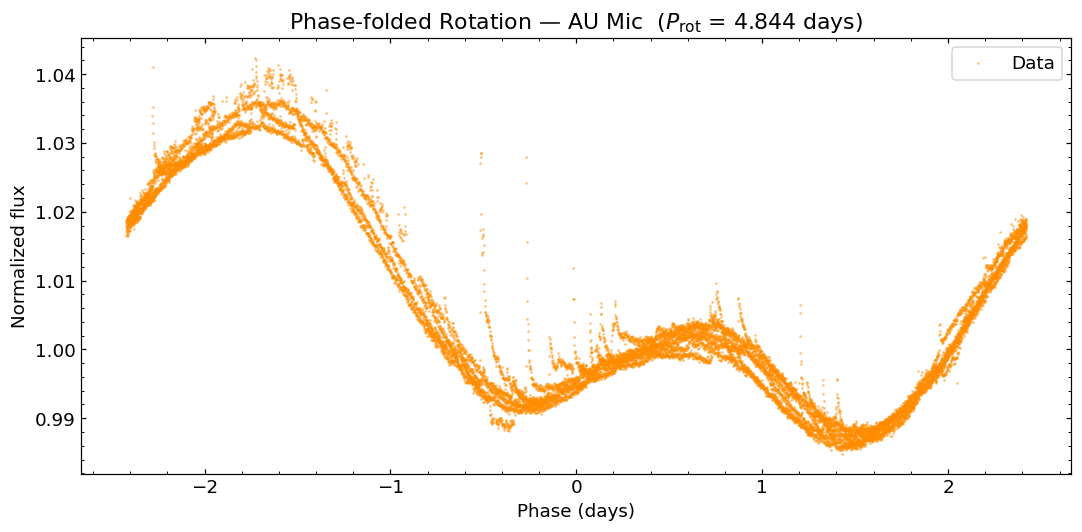

In [22]:
# Phase-fold on the best rotation period
lc_rot_folded = lc_rot.fold(period=best_rot_period * u.day)


fig, ax = plt.subplots(figsize=(10, 5))
lc_rot_folded.scatter(ax=ax, s=3, alpha=0.4, color='darkorange', label='Data')

ax.set_title(
    f"Phase-folded Rotation — {ROTATION_TARGET}  ($P_\\mathrm{{rot}}$ = {best_rot_period:.3f} days)"
)
ax.set_xlabel("Phase (days)")
ax.set_ylabel("Normalized flux")
ax.legend()
plt.tight_layout()
plt.show()


---
## Summary

In this tutorial you have:

1. **Queried** TESS light curves from the MAST archive using `lightkurve.search_lightcurve`.
2. **Cleaned** raw photometric data: NaN removal, normalization, sigma-clipping.
3. **Stitched** multi-sector observations into a continuous baseline.
4. **Detected transits** with the Box Least Squares (BLS) algorithm and measured transit
   depth and duration.
5. **Measured a stellar rotation period** with the Lomb-Scargle periodogram, assessed
   significance via false alarm probabilities, and phase-folded the light curve.


